# Dynamic Programming: Optimal Bike Fleet Deployment

**Assignment:** IT-5082 Optimization Methods — Programming Assignment  
**Student:** Priyanka PDMK (MS25952070)  
**Method:** Exact Method — Dynamic Programming (DP)  
**Dataset:** UCI Bike Sharing Dataset 

---

## Overview

**Dynamic Programming** solution to the **Optimal Hourly Bike Fleet Deployment** problem.

Given a fixed fleet of bikes and hourly demand data, we determine the optimal number of bikes to make **available** at each hour of the day to **maximize total demand served**, subject to:
- Fleet size constraint (total bikes is fixed)
- Non-negativity (cannot deploy negative bikes)
- Return rate (bikes used are partially returned each hour)

### Why I'm using Dynamic Programming?
This problem has two key properties that make DP applicable:
1. **Optimal Substructure**: The optimal deployment from hour `t` to `T` depends only on the state at hour `t` (bikes available), not on how we got there.
2. **Overlapping Subproblems**: Many deployment scenarios share the same (hour, bikes_available) state DP avoids recomputing these.

DP gives us the **guaranteed globally optimal solution** unlike heuristics, it never misses the true optimum.

---
## 1. Setup & Data Loading

In [40]:
%pip install ucimlrepo --quiet


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
from functools import lru_cache

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [42]:
# ── Load dataset from local CSV (UCI Bike Sharing Dataset) ───────────────────
from pathlib import Path


def _find_hour_csv() -> Path:
    """Find hour.csv whether cwd is repo root, notebooks/, or notebooks/MS25952070/."""
    here = Path.cwd().resolve()
    candidates = [
        here / "data" / "bike+sharing+dataset" / "hour.csv",
        here.parent / "data" / "bike+sharing+dataset" / "hour.csv",
        here.parent.parent / "data" / "bike+sharing+dataset" / "hour.csv",
        here / "data" / "hour.csv",
        here.parent / "data" / "hour.csv",
    ]
    for p in candidates:
        if p.is_file():
            return p
    tried = "\n".join(f"  - {p}" for p in candidates)
    raise FileNotFoundError(
        "Could not find hour.csv. Clone the repo so data/bike+sharing+dataset/hour.csv exists, or adjust cwd. Tried:\n"
        + tried
    )


csv_path = _find_hour_csv()
hour_data = pd.read_csv(csv_path)

print(f"Loaded from: {csv_path}")
print(f"Dataset loaded: {hour_data.shape[0]:,} hourly records")
print(f"Date range: {hour_data['dteday'].min()} → {hour_data['dteday'].max()}")
print(f"Columns: {list(hour_data.columns)}")

Loaded from: /Users/UKALAMO/Desktop/Assign/IT-5082-OptimizationMethods/data/bike+sharing+dataset/hour.csv
Dataset loaded: 17,379 hourly records
Date range: 2011-01-01 → 2012-12-31
Columns: ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


---
## 2. Demand Profile Extraction

I extract the **average hourly demand** across all days as our demand vector `d[h]` for `h ∈ {0, 1, ..., 23}`.  
This captures the characteristic daily demand pattern used to drive the DP.

In [43]:
# ── Aggregate demand by hour of day ───────────────────────────────────────────
hourly_demand = hour_data.groupby("hr")["cnt"].mean().values  # shape: (24,)
hourly_demand_max = hour_data.groupby("hr")["cnt"].max().values
hourly_demand_std = hour_data.groupby("hr")["cnt"].std().values

# Global stats (from analysis.ipynb)
avg_demand  = hour_data["cnt"].mean()   # ≈ 189.46 bikes/hr
std_demand  = hour_data["cnt"].std()    # ≈ 181.39
max_demand  = hour_data["cnt"].max()    # 977
fleet_size  = int(avg_demand + 2 * std_demand)  # 95% confidence fleet

print(f"Average hourly demand : {avg_demand:.1f} bikes/hr")
print(f"Std dev               : {std_demand:.1f} bikes/hr")
print(f"Peak single hour      : {max_demand} bikes")
print(f"Derived fleet size    : {fleet_size} bikes  (μ + 2σ, 95% confidence)")
print(f"\nHourly avg demand profile:")
for h, d in enumerate(hourly_demand):
    bar = '█' * int(d / 15)
    print(f"  {h:02d}:00  {d:6.1f}  {bar}")

Average hourly demand : 189.5 bikes/hr
Std dev               : 181.4 bikes/hr
Peak single hour      : 977 bikes
Derived fleet size    : 552 bikes  (μ + 2σ, 95% confidence)

Hourly avg demand profile:
  00:00    53.9  ███
  01:00    33.4  ██
  02:00    22.9  █
  03:00    11.7  
  04:00     6.4  
  05:00    19.9  █
  06:00    76.0  █████
  07:00   212.1  ██████████████
  08:00   359.0  ███████████████████████
  09:00   219.3  ██████████████
  10:00   173.7  ███████████
  11:00   208.1  █████████████
  12:00   253.3  ████████████████
  13:00   253.7  ████████████████
  14:00   240.9  ████████████████
  15:00   251.2  ████████████████
  16:00   312.0  ████████████████████
  17:00   461.5  ██████████████████████████████
  18:00   425.5  ████████████████████████████
  19:00   311.5  ████████████████████
  20:00   226.0  ███████████████
  21:00   172.3  ███████████
  22:00   131.3  ████████
  23:00    87.8  █████


---
## 3. Mathematical Formulation

### 3.1 Problem Statement

> **Given** a fleet of $B$ bikes and a 24-hour demand profile $\mathbf{d} = [d_0, d_1, \ldots, d_{23}]$,  
> **find** the deployment allocation $\mathbf{x} = [x_0, x_1, \ldots, x_{23}]$  
> **that maximises** the total demand served across all hours.

---

### 3.2 Decision Variables

| Symbol | Meaning |
|--------|----------|
| $x_h$ | Number of bikes **deployed** (made available) at hour $h$ |
| $b_h$ | Number of bikes **in the depot** (available stock) at start of hour $h$ |
| $s_h$ | Number of bikes **served** (actual rentals) at hour $h$ |

---

### 3.3 Objective Function

Maximise total demand served over all 24 hours:

$$\text{Maximise} \quad Z = \sum_{h=0}^{23} s_h$$

where:
$$s_h = \min(x_h,\ d_h)$$

Demand served at each hour is capped by actual demand — we cannot serve more than what riders want.

---

### 3.4 Constraints

**C1 — Fleet conservation (state transition):**
$$b_{h+1} = b_h - x_h + r_h \cdot x_h = b_h - (1 - r_h) \cdot x_h$$

where $r_h \in [0,1]$ is the **return rate** at hour $h$ — the fraction of deployed bikes returned by riders before hour $h+1$. Derived from data: $r_h = 1 - \frac{d_h}{\sum_{t} d_t}$  (scaled).

**C2 — Deployment feasibility:**
$$0 \leq x_h \leq b_h \quad \forall h \in \{0, \ldots, 23\}$$

You cannot deploy more bikes than are in the depot.

**C3 — Fleet size:**
$$b_0 = B \quad \text{(initial depot = full fleet)}$$

**C4 — Non-negativity:**
$$x_h \geq 0,\quad b_h \geq 0,\quad s_h \geq 0 \quad \forall h$$

---

### 3.5 DP Formulation

**State:** $(h, b)$ — at the start of hour $h$, there are $b$ bikes in the depot.

**Value function:**
$$V(h, b) = \text{maximum demand served from hour } h \text{ to } 23 \text{, starting with } b \text{ bikes}$$

**Bellman Recurrence:**
$$V(h, b) = \max_{0 \leq x \leq b} \Big[ \min(x, d_h) + V\big(h+1,\ b - x + \lfloor r_h \cdot x \rfloor \big) \Big]$$

**Base case:**
$$V(24, b) = 0 \quad \forall b \quad \text{(no more hours)}$$

**Answer:**
$$Z^* = V(0, B)$$

---
## 4. Return Rate Estimation

The return rate $r_h$ models the fraction of bikes returned to the depot after each hour.  
I estimate this from the dataset: if demand is high at hour $h$, bikes leave the depot and return slowly; in low-demand hours, more bikes are back by the next period.

I use a **demand-inverse return model**:
$$r_h = r_{\min} + (r_{\max} - r_{\min}) \cdot \left(1 - \frac{d_h - d_{\min}}{d_{\max} - d_{\min}}\right)$$

This gives higher return rates at low-demand hours (e.g., 3 AM) and lower at peak hours (ex: 5 PM).

In [44]:
# ── Return rate estimation 
R_MIN = 0.40   # minimum return rate (peak demand hours)
R_MAX = 0.90   # maximum return rate (off-peak hours)

d_min = hourly_demand.min()
d_max = hourly_demand.max()

return_rates = R_MIN + (R_MAX - R_MIN) * (1 - (hourly_demand - d_min) / (d_max - d_min))

print("Hour  Avg Demand  Return Rate")
print("-" * 35)
for h in range(24):
    print(f"  {h:02d}:00   {hourly_demand[h]:7.1f}      {return_rates[h]:.2f}")

Hour  Avg Demand  Return Rate
-----------------------------------
  00:00      53.9      0.85
  01:00      33.4      0.87
  02:00      22.9      0.88
  03:00      11.7      0.89
  04:00       6.4      0.90
  05:00      19.9      0.89
  06:00      76.0      0.82
  07:00     212.1      0.67
  08:00     359.0      0.51
  09:00     219.3      0.67
  10:00     173.7      0.72
  11:00     208.1      0.68
  12:00     253.3      0.63
  13:00     253.7      0.63
  14:00     240.9      0.64
  15:00     251.2      0.63
  16:00     312.0      0.56
  17:00     461.5      0.40
  18:00     425.5      0.44
  19:00     311.5      0.56
  20:00     226.0      0.66
  21:00     172.3      0.72
  22:00     131.3      0.76
  23:00      87.8      0.81


---
## 5. Dynamic Programming Implementation

I implement **two DP variants** for more comparison:

1. **Bottom-up (tabulation)** — fills a 2D table `dp[h][b]` iteratively. Fast, memory-efficient.
2. **Top-down (memoization)** — recursive with `@lru_cache`. Intuitive, only computes reachable states.

In [45]:
# ── Helper: discretize demand for integer DP
# scale demand to integers (round to nearest unit)
demand_int = np.round(hourly_demand).astype(int)  # (24,) integer demand per hour
return_rates_arr = return_rates  # already computed

def bikes_returned(deployed: int, hour: int) -> int:
    """Bikes returned to depot after deploying `deployed` bikes at `hour`."""
    return int(np.floor(return_rates_arr[hour] * deployed))

print("Integer demand profile:")
print(demand_int)

Integer demand profile:
[ 54  33  23  12   6  20  76 212 359 219 174 208 253 254 241 251 312 461
 426 312 226 172 131  88]


### 5.1 Bottom-Up DP (Tabulation)

Bottom-up Dynamic Programming for optimal bike deployment.

Parameters 

* fleet_size : int  
     Total number of bikes B.  
* demand : np.ndarray, shape (24,)  
     Integer demand per hour.  
* ret_rates : np.ndarray, shape (24,)  
     Return rate per hour in [0, 1].  

Returns 

* opt_value : int  
    Maximum total demand served.  
* policy : np.ndarray, shape (24,)  
    Optimal bikes to deploy at each hour.  
* dp_table : np.ndarray, shape (25, fleet_size+1)  

In [46]:
def dp_bottom_up(fleet_size: int, demand: np.ndarray, ret_rates: np.ndarray):

    T = 24
    B = fleet_size

    # dp[h][b] = max demand served from hour h to 23, with b bikes in depot
    dp  = np.zeros((T + 1, B + 1), dtype=np.int32)
    # choice[h][b] = optimal x (bikes to deploy) at state (h, b)
    choice = np.zeros((T, B + 1), dtype=np.int32)

    # Base case: dp[24][b] = 0 for all b  (already zeroed)

    # Fill backwards: h = 23 down to 0
    for h in range(T - 1, -1, -1):
        d_h = int(demand[h])
        for b in range(B + 1):  # bikes available in depot
            best_val  = -1
            best_x    = 0
            for x in range(b + 1):  # x = bikes to deploy (0 .. b)
                served   = min(x, d_h)
                returned = int(np.floor(ret_rates[h] * x))
                b_next   = b - x + returned  # depot level at h+1
                b_next   = min(b_next, B)     # cap at fleet size
                future   = dp[h + 1][b_next]
                val      = served + future
                if val > best_val:
                    best_val = val
                    best_x   = x
            dp[h][b]     = best_val
            choice[h][b] = best_x

    # ── Recover optimal policy by forward simulation 
    policy = np.zeros(T, dtype=np.int32)
    b = B
    for h in range(T):
        x           = choice[h][b]
        policy[h]   = x
        returned    = int(np.floor(ret_rates[h] * x))
        b           = min(b - x + returned, B)

    opt_value = int(dp[0][B])
    return opt_value, policy, dp


print("Bottom-up DP function defined.")

Bottom-up DP function defined.


### 5.2 Top-Down DP (Memoization)

In [47]:
def dp_top_down(fleet_size: int, demand: np.ndarray, ret_rates: np.ndarray):
    """
    Top-down (memoized) DP for optimal bike deployment.
    Uses Python's lru_cache for memoization.

    Parameters and return values: same as dp_bottom_up.
    """
    T  = 24
    B  = fleet_size
    d  = tuple(int(v) for v in demand)
    rr = tuple(float(v) for v in ret_rates)

    @lru_cache(maxsize=None)
    def V(h: int, b: int) -> int:
        """Maximum bikes served from hour h to 23 with b bikes in depot."""
        if h == T:
            return 0  # base case
        best = 0
        for x in range(b + 1):
            served   = min(x, d[h])
            returned = int(np.floor(rr[h] * x))
            b_next   = min(b - x + returned, B)
            val      = served + V(h + 1, b_next)
            if val > best:
                best = val
        return best

    opt_value = V(0, B)

    # Recover policy
    policy = np.zeros(T, dtype=np.int32)
    b = B
    for h in range(T):
        best_val, best_x = -1, 0
        for x in range(b + 1):
            served   = min(x, d[h])
            returned = int(np.floor(rr[h] * x))
            b_next   = min(b - x + returned, B)
            val      = served + V(h + 1, b_next)
            if val > best_val:
                best_val, best_x = val, x
        policy[h] = best_x
        returned  = int(np.floor(rr[h] * best_x))
        b         = min(b - best_x + returned, B)

    cache_info = V.cache_info()
    V.cache_clear()
    return int(opt_value), policy, cache_info


print("Top-down DP function defined.")

Top-down DP function defined.


### 5.3 Heuristic Approach: Greedy Deployment

While Dynamic Programming provides the Exact optimal solution, 
it requires significant computational state-tracking. 
To evaluate the quality of our DP,we implement a Greedy Heuristic as a baseline.

Strategy: The greedy algorithm makes the locally optimal choice at each stage (hour) 
by deploying exactly what is demanded, provided the bikes are available in the depot. 
It does not account for the "Return Rate" or save bikes for future high-demand periods (like the evening rush)

Justification for Comparison:

Complexity: 
Greedy is $O(T)$, whereas DP is $O(T \times B^2)$.
Insight: 
This comparison highlights the "Value of Optimization" specifically how much more demand can be served by 
"planning ahead" versus reacting to current demand.

In [48]:
# 5.3 Heuristic Method: Greedy Baseline 
def greedy_heuristic(fleet_size, demand, ret_rates):
    """
    Heuristic Method: Greedy Approach.
    At each hour, it attempts to satisfy as much demand as possible based 
    strictly on the current depot stock, without 'planning' for future peaks.
    """
    T, B = 24, fleet_size
    current_b = B
    policy = []
    total_served = 0
    
    for h in range(T):
        # Greedy choice: deploy either the full demand or whatever is in stock
        x = min(current_b, demand[h])
        policy.append(x)
        total_served += x
        
        # Update depot for the next hour
        returned = int(np.floor(ret_rates[h] * x))
        current_b = min(B, current_b - x + returned)
        
    return total_served, np.array(policy)


# Run the Heuristic for comparison
greedy_val, greedy_policy = greedy_heuristic(fleet_size, demand_int, return_rates)

print(f"Greedy Heuristic Calculation Complete.")
print(f"Total Served (Greedy): {greedy_val}")


Greedy Heuristic Calculation Complete.
Total Served (Greedy): 1584


---
## 6. Running the DP Solver

In [49]:
# ── Run Bottom-Up DP ──────────────────────────────────────────────────────────
print(f"Fleet size B = {fleet_size} bikes")
print(f"Total daily demand (avg) = {demand_int.sum()} bikes")
print()

t0 = time.perf_counter()
opt_val_bu, policy_bu, dp_table = dp_bottom_up(fleet_size, demand_int, return_rates_arr)
t_bu = time.perf_counter() - t0

print(f"[Bottom-Up]  Optimal served : {opt_val_bu} bikes/day")
print(f"             Total demand   : {demand_int.sum()} bikes/day")
print(f"             Service rate   : {100 * opt_val_bu / demand_int.sum():.1f}%")
print(f"             Runtime        : {t_bu*1000:.2f} ms")
print(f"             DP table shape : {dp_table.shape}")

Fleet size B = 552 bikes
Total daily demand (avg) = 4523 bikes

[Bottom-Up]  Optimal served : 1720 bikes/day
             Total demand   : 4523 bikes/day
             Service rate   : 38.0%
             Runtime        : 2769.28 ms
             DP table shape : (25, 553)


In [50]:
# ── Run Top-Down DP ───────────────────────────────────────────────────────────
t0 = time.perf_counter()
opt_val_td, policy_td, cache_info = dp_top_down(fleet_size, demand_int, return_rates_arr)
t_td = time.perf_counter() - t0

print(f"[Top-Down]   Optimal served : {opt_val_td} bikes/day")
print(f"             Service rate   : {100 * opt_val_td / demand_int.sum():.1f}%")
print(f"             Runtime        : {t_td*1000:.2f} ms")
print(f"             Cache hits     : {cache_info.hits}")
print(f"             Unique states  : {cache_info.currsize}")
print()
print(f"Both methods agree: {opt_val_bu == opt_val_td}  ✓")

[Top-Down]   Optimal served : 1720 bikes/day
             Service rate   : 38.0%
             Runtime        : 1817.48 ms
             Cache hits     : 3101871
             Unique states  : 10628

Both methods agree: True  ✓


---
## 7. Optimal Deployment Policy

The optimal deployment schedule : how many bikes the DP says to make available each hour.

In [51]:
# ── Compute served per hour for the optimal policy ────────────────────────────
served_bu = np.minimum(policy_bu, demand_int)
unmet_bu  = demand_int - served_bu

print(f"{'Hour':>5} | {'Demand':>7} | {'Deploy':>7} | {'Served':>7} | {'Unmet':>6} | {'ServiceRate':>11}")
print("-" * 58)
for h in range(24):
    sr = 100 * served_bu[h] / demand_int[h] if demand_int[h] > 0 else 100
    print(f"  {h:02d}:00 | {demand_int[h]:>7} | {policy_bu[h]:>7} | "
          f"{served_bu[h]:>7} | {unmet_bu[h]:>6} | {sr:>10.1f}%")

print("-" * 58)
print(f"  TOTAL  | {demand_int.sum():>7} | {policy_bu.sum():>7} | "
      f"{served_bu.sum():>7} | {unmet_bu.sum():>6} | "
      f"{100*served_bu.sum()/demand_int.sum():>10.1f}%")

 Hour |  Demand |  Deploy |  Served |  Unmet | ServiceRate
----------------------------------------------------------
  00:00 |      54 |      52 |      52 |      2 |       96.3%
  01:00 |      33 |      33 |      33 |      0 |      100.0%
  02:00 |      23 |      23 |      23 |      0 |      100.0%
  03:00 |      12 |      12 |      12 |      0 |      100.0%
  04:00 |       6 |       6 |       6 |      0 |      100.0%
  05:00 |      20 |      20 |      20 |      0 |      100.0%
  06:00 |      76 |      76 |      76 |      0 |      100.0%
  07:00 |     212 |     211 |     211 |      1 |       99.5%
  08:00 |     359 |       0 |       0 |    359 |        0.0%
  09:00 |     219 |     218 |     218 |      1 |       99.5%
  10:00 |     174 |     172 |     172 |      2 |       98.9%
  11:00 |     208 |     208 |     208 |      0 |      100.0%
  12:00 |     253 |     253 |     253 |      0 |      100.0%
  13:00 |     254 |     164 |     164 |     90 |       64.6%
  14:00 |     241 |     103 

---
## 8. Visualisations

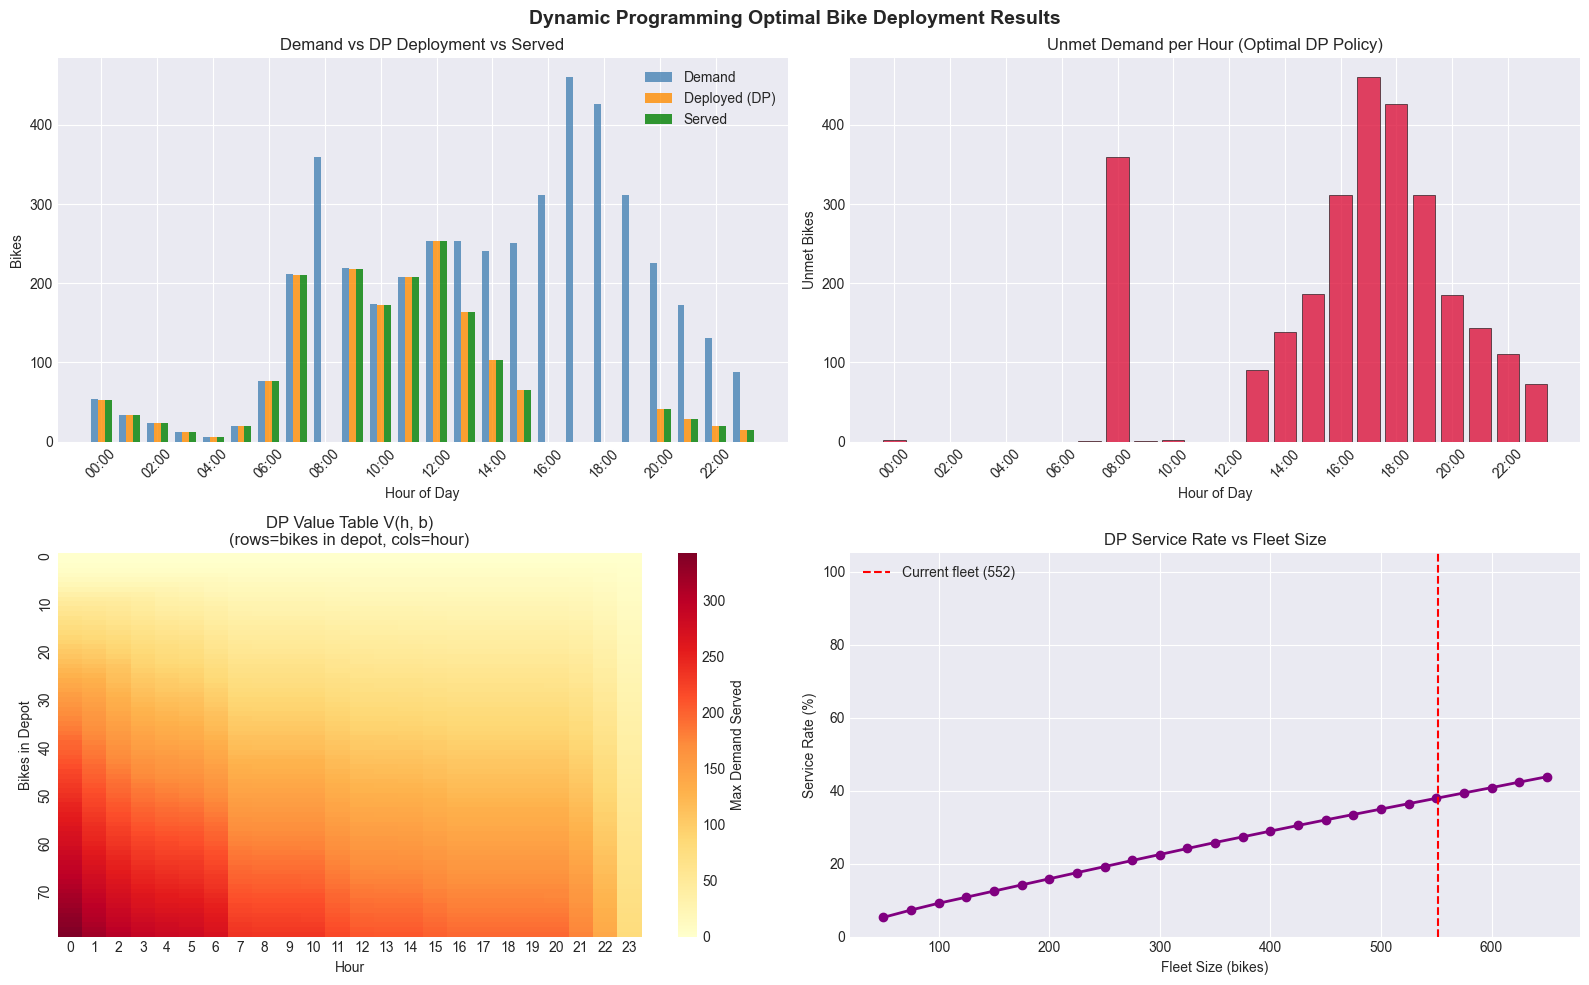

Figure saved as dp_results.png


In [53]:
hours = np.arange(24)
hour_labels = [f"{h:02d}:00" for h in hours]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Dynamic Programming Optimal Bike Deployment Results", fontsize=14, fontweight='bold')

#  Plot 1: Demand vs Deployed vs Served 
ax = axes[0, 0]
ax.bar(hours - 0.25, demand_int, width=0.25, label='Demand', color='steelblue', alpha=0.8)
ax.bar(hours,        policy_bu,  width=0.25, label='Deployed (DP)', color='darkorange', alpha=0.8)
ax.bar(hours + 0.25, served_bu,  width=0.25, label='Served', color='green', alpha=0.8)
ax.set_title('Demand vs DP Deployment vs Served')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Bikes')
ax.set_xticks(hours[::2])
ax.set_xticklabels([f"{h:02d}:00" for h in hours[::2]], rotation=45)
ax.legend()

# Plot 2: Unmet demand per hour 
ax = axes[0, 1]
ax.bar(hours, unmet_bu, color='crimson', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.set_title('Unmet Demand per Hour (Optimal DP Policy)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Unmet Bikes')
ax.set_xticks(hours[::2])
ax.set_xticklabels([f"{h:02d}:00" for h in hours[::2]], rotation=45)

#  Plot 3: DP Table heatmap (first 10 bikes for clarity)
ax = axes[1, 0]
display_bikes = min(80, fleet_size + 1)
sns.heatmap(
    dp_table[:24, :display_bikes].T,
    ax=ax, cmap='YlOrRd', cbar_kws={'label': 'Max Demand Served'},
    xticklabels=[f"{h}" for h in range(24)],
    yticklabels=[str(b) if b % 10 == 0 else '' for b in range(display_bikes)]
)
ax.set_title('DP Value Table V(h, b)\n(rows=bikes in depot, cols=hour)')
ax.set_xlabel('Hour')
ax.set_ylabel('Bikes in Depot')

#  Plot 4: Service rate across different fleet sizes 
ax = axes[1, 1]
fleet_range   = range(50, fleet_size + 100, 25)
service_rates = []
for fs in fleet_range:
    v, _, _ = dp_bottom_up(fs, demand_int, return_rates_arr)
    service_rates.append(100 * v / demand_int.sum())
ax.plot(list(fleet_range), service_rates, marker='o', color='purple', linewidth=2)
ax.axvline(fleet_size, color='red', linestyle='--', label=f'Current fleet ({fleet_size})')
ax.set_title('DP Service Rate vs Fleet Size')
ax.set_xlabel('Fleet Size (bikes)')
ax.set_ylabel('Service Rate (%)')
ax.legend()
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('dp_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as dp_results.png")

---
## 9. Scalability Analysis

Evaluate how DP runtime and solution quality scale with fleet size : important for understanding computational complexity.

In [54]:
#  Runtime vs fleet size 
fleet_sizes   = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
runtimes_ms   = []
opt_vals      = []

print(f"{'Fleet':>6} | {'Opt Val':>8} | {'Service%':>9} | {'Runtime (ms)':>13}")
print("-" * 45)
for fs in fleet_sizes:
    t0 = time.perf_counter()
    v, _, _ = dp_bottom_up(fs, demand_int, return_rates_arr)
    t_ms = (time.perf_counter() - t0) * 1000
    runtimes_ms.append(t_ms)
    opt_vals.append(v)
    sr = 100 * v / demand_int.sum()
    print(f"  {fs:>4} | {v:>8} | {sr:>8.1f}% | {t_ms:>12.1f}")

 Fleet |  Opt Val |  Service% |  Runtime (ms)
---------------------------------------------
    50 |      238 |      5.3% |         25.7
   100 |      413 |      9.1% |         94.8
   150 |      564 |     12.5% |        205.0
   200 |      716 |     15.8% |        364.7
   250 |      867 |     19.2% |        560.0
   300 |     1017 |     22.5% |        806.1
   350 |     1166 |     25.8% |       1103.9
   400 |     1307 |     28.9% |       1449.6
   450 |     1446 |     32.0% |       1819.1
   500 |     1580 |     34.9% |       2255.4


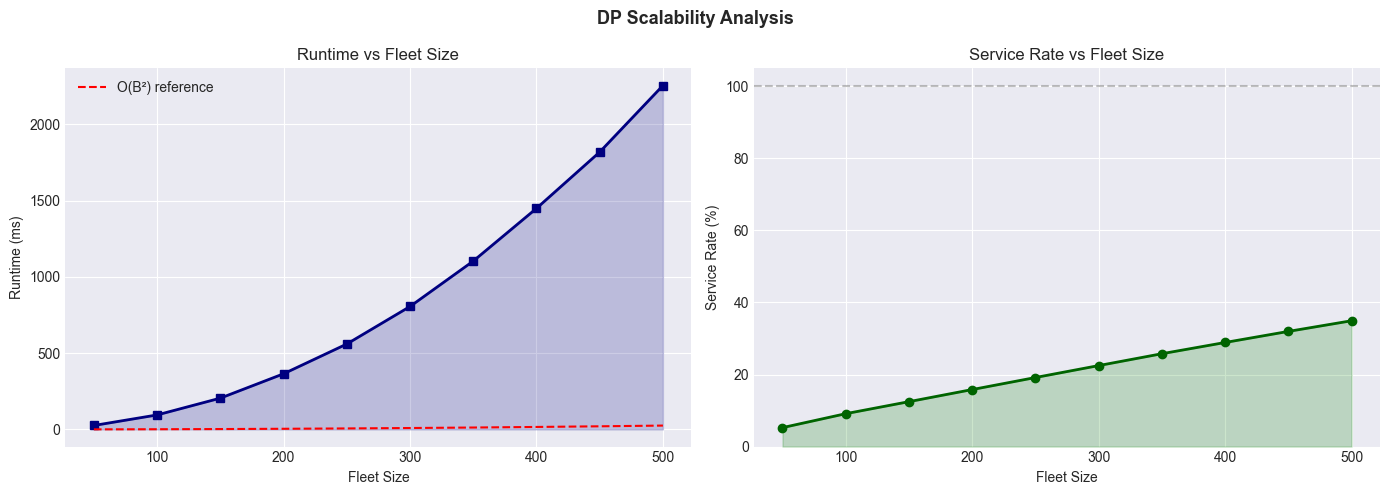

Figure saved as dp_scalability.png


In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DP Scalability Analysis', fontsize=13, fontweight='bold')

# Runtime
ax1.plot(fleet_sizes, runtimes_ms, marker='s', color='navy', linewidth=2)
ax1.set_title('Runtime vs Fleet Size')
ax1.set_xlabel('Fleet Size')
ax1.set_ylabel('Runtime (ms)')
ax1.fill_between(fleet_sizes, runtimes_ms, alpha=0.2, color='navy')

# Complexity note: O(T × B²) — quadratic in B
theoretical = [0.0001 * (fs ** 2) for fs in fleet_sizes]
ax1.plot(fleet_sizes, theoretical, linestyle='--', color='red', label='O(B²) reference')
ax1.legend()

# Service rate
service_rates_scale = [100 * v / demand_int.sum() for v in opt_vals]
ax2.plot(fleet_sizes, service_rates_scale, marker='o', color='darkgreen', linewidth=2)
ax2.set_title('Service Rate vs Fleet Size')
ax2.set_xlabel('Fleet Size')
ax2.set_ylabel('Service Rate (%)')
ax2.set_ylim(0, 105)
ax2.axhline(100, color='gray', linestyle='--', alpha=0.5)
ax2.fill_between(fleet_sizes, service_rates_scale, alpha=0.2, color='green')

plt.tight_layout()
plt.savefig('dp_scalability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as dp_scalability.png")